# 5.2 — Multivariate Prediction: Do Latent Features Add Clinical Value?

## Scientific question
The correlation analysis (5.1) showed that individual latent dimensions correlate with UPDRS-III, MoCA, and Hoehn & Yahr. But does the **combination** of latent  
features predict clinical scores better than just knowing a patient's age and sex?

## What this notebook does
1. Defines three prediction models per clinical target:
   - **Baseline** — age + sex only (what demographics alone can predict)
   - **Imaging** — biological latent dimensions only (what imaging alone predicts)
   - **Combined** — age + sex + biological latent dimensions (full model)
2. Evaluates each model using 5-fold cross-validation on the training set
3. Reports R² and MAE for regression targets, accuracy for ordinal targets
4. Tests whether the imaging model significantly outperforms the demographic baseline
5. Produces a comparison figure

## Why this matters
If imaging adds predictive value beyond demographics, it demonstrates that  
unsupervised deep learning extracts clinically useful information not captured  
by simple patient characteristics — a key contribution for publication.


## 1. Imports and Configuration

In [25]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats


BETA_SUFFIX = 'beta_3e5'

# ── Paths 
TRAIN_FILE   = f'../../data/processed/clinical_merged/train_{BETA_SUFFIX}.csv'
ANCOVA_FILE  = f'../../results/correlation/ancova_results_{BETA_SUFFIX}.csv'
OUTPUT_DIR   = '../../results/prediction'
FIGURES_DIR  = '../../results/figures'
    

import os
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Parameters
PATIENT_COL   = 'PATNO'
LABEL_COL     = 'label'
LATENT_COLS   = [f'latent_{i}' for i in range(256)]
N_FOLDS       = 5
RANDOM_STATE  = 42

# Clinical targets to predict
TARGETS = {
    'UPDRS3_TOTAL': 'UPDRS-III (motor severity)',
    'MOCA_TOTAL':   'MoCA (cognition)',
    'HOEHN_YAHR':   'Hoehn & Yahr (disease stage)',
}

# Demographic features (baseline model)
DEMOGRAPHIC_FEATURES = ['AGE_AT_VISIT', 'SEX']

print("Configuration loaded.")
print(f"  Targets:    {list(TARGETS.keys())}")
print(f"  CV folds:   {N_FOLDS}")

Configuration loaded.
  Targets:    ['UPDRS3_TOTAL', 'MOCA_TOTAL', 'HOEHN_YAHR']
  CV folds:   5


## 2. Load Data

In [26]:
# LOAD-DATA

df_train  = pd.read_csv(TRAIN_FILE)
df_ancova = pd.read_csv(ANCOVA_FILE)

# Load validation results from correlation analysis
df_val_results = pd.read_csv(f'../../results/correlation/correlation_val_{BETA_SUFFIX}.csv')

# Use dims validated for clinical factors instead of ANCOVA-only
# (ANCOVA is incomplete without Manufacturer)
clinical_validated_cols = [
    'UPDRS3_TOTAL_validated',
    'MOCA_TOTAL_validated',
    'HOEHN_YAHR_validated',
    'NP3_PC2_validated'
]
clinical_validated_cols = [c for c in clinical_validated_cols
                            if c in df_val_results.columns]

biological_dims = df_val_results[
    df_val_results[clinical_validated_cols].any(axis=1)
]['dimension'].tolist()

print(f"Train shape:     {df_train.shape}")
print(f"Biological dims: {len(biological_dims)}")
print(f"Dims list:       {biological_dims}")

print(f"\nTarget coverage in training set:")
for target, label in TARGETS.items():
    if target in df_train.columns:
        n   = df_train[target].notna().sum()
        pct = n / len(df_train) * 100
        print(f"  {label:<35} {n} rows ({pct:.1f}%)")

Train shape:     (3085, 275)
Biological dims: 75
Dims list:       ['latent_2', 'latent_3', 'latent_7', 'latent_8', 'latent_10', 'latent_11', 'latent_15', 'latent_17', 'latent_20', 'latent_26', 'latent_29', 'latent_31', 'latent_34', 'latent_41', 'latent_51', 'latent_52', 'latent_55', 'latent_66', 'latent_69', 'latent_70', 'latent_76', 'latent_79', 'latent_83', 'latent_85', 'latent_86', 'latent_90', 'latent_91', 'latent_98', 'latent_99', 'latent_102', 'latent_106', 'latent_111', 'latent_112', 'latent_113', 'latent_114', 'latent_116', 'latent_117', 'latent_124', 'latent_129', 'latent_132', 'latent_133', 'latent_141', 'latent_145', 'latent_147', 'latent_150', 'latent_151', 'latent_167', 'latent_169', 'latent_171', 'latent_173', 'latent_175', 'latent_180', 'latent_185', 'latent_192', 'latent_196', 'latent_203', 'latent_205', 'latent_206', 'latent_211', 'latent_214', 'latent_216', 'latent_218', 'latent_221', 'latent_222', 'latent_225', 'latent_227', 'latent_228', 'latent_232', 'latent_234', 

## 3. Prediction Framework
For each clinical target we run three models:
- **Baseline** — age + sex only
- **Imaging** — biological latent dimensions only  
- **Combined** — age + sex + biological latent dimensions

Each model is evaluated with 5-fold cross-validation.  
We use Ridge regression — appropriate for many correlated features.  
Standard scaling is applied inside each fold to prevent data leakage.


In [27]:
# PREDICTION-FRAMEWORK
def run_cv_prediction(df, feature_cols, target_col, n_folds=5, random_state=42):
    """
    Run k-fold cross-validation for predicting target_col from feature_cols.
    Returns dict with mean R2, std R2, mean MAE, std MAE.
    """
    # Drop rows with missing values in features or target
    cols_needed = feature_cols + [target_col, PATIENT_COL]
    data = df[cols_needed].dropna().copy()

    if len(data) < 50:
        return {'r2_mean': np.nan, 'r2_std': np.nan,
                'mae_mean': np.nan, 'mae_std': np.nan,
                'n_samples': len(data)}

    X = data[feature_cols].values
    y = data[target_col].values

    # Use unique patients for fold assignment to avoid leakage
    unique_patients = data[PATIENT_COL].unique()
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    r2_scores  = []
    mae_scores = []

    for train_idx, val_idx in kf.split(unique_patients):
        train_patients = unique_patients[train_idx]
        val_patients   = unique_patients[val_idx]

        train_mask = data[PATIENT_COL].isin(train_patients)
        val_mask   = data[PATIENT_COL].isin(val_patients)

        X_train, X_val = X[train_mask], X[val_mask]
        y_train, y_val = y[train_mask], y[val_mask]

        if len(X_val) < 5:
            continue

        # Scale inside fold — fit on train, apply to val
        scaler = StandardScaler()
        # print("X_train", X_train)
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled   = scaler.transform(X_val)

        # Ridge regression
        model = Ridge(alpha=1.0)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)

        r2_scores.append(r2_score(y_val, y_pred))
        mae_scores.append(mean_absolute_error(y_val, y_pred))

    return {
        'r2_mean':   np.mean(r2_scores),
        'r2_std':    np.std(r2_scores),
        'mae_mean':  np.mean(mae_scores),
        'mae_std':   np.std(mae_scores),
        'n_samples': len(data)
    }

print("Prediction framework defined.")
print("  Model: Ridge regression")
print("  CV: Patient-stratified 5-fold")
print("  Scaling: StandardScaler fit inside each fold")

Prediction framework defined.
  Model: Ridge regression
  CV: Patient-stratified 5-fold
  Scaling: StandardScaler fit inside each fold


## 4. Run Predictions for All Targets and Models

In [28]:
# RUN-PREDICTIONS
results = []

df_train['SEX'] = df_train['Sex'].map({'F': 0, 'M': 1})
# print(df_train.head(3))

for target, target_label in TARGETS.items():
    if target not in df_train.columns:
        print(f"Skipping {target} — not in dataset")
        continue

    print(f"\nPredicting: {target_label}")
    print("-" * 50)

    models = {
        'Baseline (Age + Sex)':        DEMOGRAPHIC_FEATURES,
        'Imaging (Biological dims)':   biological_dims,
        'Combined (Age + Sex + Dims)': DEMOGRAPHIC_FEATURES + biological_dims,
    }

    for model_name, features in models.items():
        # Check all features exist
        available = [f for f in features if f in df_train.columns]
        if len(available) < len(features):
            missing = set(features) - set(available)
            print(f"  Warning: {missing} not in dataset, skipping")
            continue

        res = run_cv_prediction(df_train, available, target)
        res['target']      = target
        res['target_label'] = target_label
        res['model']       = model_name
        res['n_features']  = len(available)
        results.append(res)

        print(f"  {model_name:<35} R²={res['r2_mean']:>6.3f} ± {res['r2_std']:.3f}   MAE={res['mae_mean']:.2f} ± {res['mae_std']:.2f}   (n={res['n_samples']})")

df_results = pd.DataFrame(results)
df_results.to_csv(f'{OUTPUT_DIR}/prediction_results_{BETA_SUFFIX}.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR}/prediction_results_{BETA_SUFFIX}.csv")


Predicting: UPDRS-III (motor severity)
--------------------------------------------------
  Baseline (Age + Sex)                R²= 0.023 ± 0.007   MAE=9.88 ± 0.57   (n=2499)
  Imaging (Biological dims)           R²= 0.305 ± 0.025   MAE=8.25 ± 0.40   (n=2499)
  Combined (Age + Sex + Dims)         R²= 0.305 ± 0.025   MAE=8.26 ± 0.42   (n=2499)

Predicting: MoCA (cognition)
--------------------------------------------------
  Baseline (Age + Sex)                R²= 0.080 ± 0.034   MAE=1.94 ± 0.03   (n=2886)
  Imaging (Biological dims)           R²= 0.062 ± 0.036   MAE=1.97 ± 0.04   (n=2886)
  Combined (Age + Sex + Dims)         R²= 0.082 ± 0.045   MAE=1.95 ± 0.04   (n=2886)

Predicting: Hoehn & Yahr (disease stage)
--------------------------------------------------
  Baseline (Age + Sex)                R²=-0.008 ± 0.017   MAE=0.64 ± 0.08   (n=2499)
  Imaging (Biological dims)           R²= 0.015 ± 0.035   MAE=0.58 ± 0.03   (n=2499)
  Combined (Age + Sex + Dims)         R²= 0.013 ± 0.041

## 5. Does Imaging Add Value Beyond Demographics?
We test whether the Combined model significantly outperforms the Baseline using a paired permutation test on the cross-validation fold scores.  
A significant result means imaging adds independent predictive value.


In [29]:
# SIGNIFICANCE-TEST
print("=== Does imaging add value beyond demographics? ===\n")

for target, target_label in TARGETS.items():
    if target not in df_train.columns:
        continue

    # Get fold-level scores for baseline and combined
    cols_needed = DEMOGRAPHIC_FEATURES + biological_dims + [target, PATIENT_COL]
    data = df_train[[c for c in cols_needed if c in df_train.columns]].dropna().copy()

    if len(data) < 50:
        continue

    unique_patients = data[PATIENT_COL].unique()
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    baseline_r2 = []
    combined_r2 = []

    for train_idx, val_idx in kf.split(unique_patients):
        train_patients = unique_patients[train_idx]
        val_patients   = unique_patients[val_idx]
        train_mask = data[PATIENT_COL].isin(train_patients)
        val_mask   = data[PATIENT_COL].isin(val_patients)

        X_train_b = data[train_mask][DEMOGRAPHIC_FEATURES].values
        X_val_b   = data[val_mask][DEMOGRAPHIC_FEATURES].values
        X_train_c = data[train_mask][DEMOGRAPHIC_FEATURES + biological_dims].values
        X_val_c   = data[val_mask][DEMOGRAPHIC_FEATURES + biological_dims].values
        y_train   = data[train_mask][target].values
        y_val     = data[val_mask][target].values

        for X_tr, X_vl, store in [(X_train_b, X_val_b, baseline_r2),
                                    (X_train_c, X_val_c, combined_r2)]:
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_vl_s = scaler.transform(X_vl)
            model  = Ridge(alpha=1.0)
            model.fit(X_tr_s, y_train)
            store.append(r2_score(y_val, model.predict(X_vl_s)))

    # Paired t-test
    t_stat, p_val = stats.ttest_rel(combined_r2, baseline_r2)
    improvement   = np.mean(combined_r2) - np.mean(baseline_r2)

    sig = "✓ significant" if p_val < 0.05 else "✗ not significant"
    print(f"{target_label}:")
    print(f"  Baseline R²:  {np.mean(baseline_r2):.3f}")
    print(f"  Combined R²:  {np.mean(combined_r2):.3f}")
    print(f"  Improvement:  +{improvement:.3f}")
    print(f"  p-value:      {p_val:.4f}  {sig}")
    print()

=== Does imaging add value beyond demographics? ===

UPDRS-III (motor severity):
  Baseline R²:  0.023
  Combined R²:  0.305
  Improvement:  +0.283
  p-value:      0.0000  ✓ significant

MoCA (cognition):
  Baseline R²:  0.080
  Combined R²:  0.082
  Improvement:  +0.002
  p-value:      0.8777  ✗ not significant

Hoehn & Yahr (disease stage):
  Baseline R²:  -0.008
  Combined R²:  0.013
  Improvement:  +0.022
  p-value:      0.4705  ✗ not significant



## 6. Results Visualisation

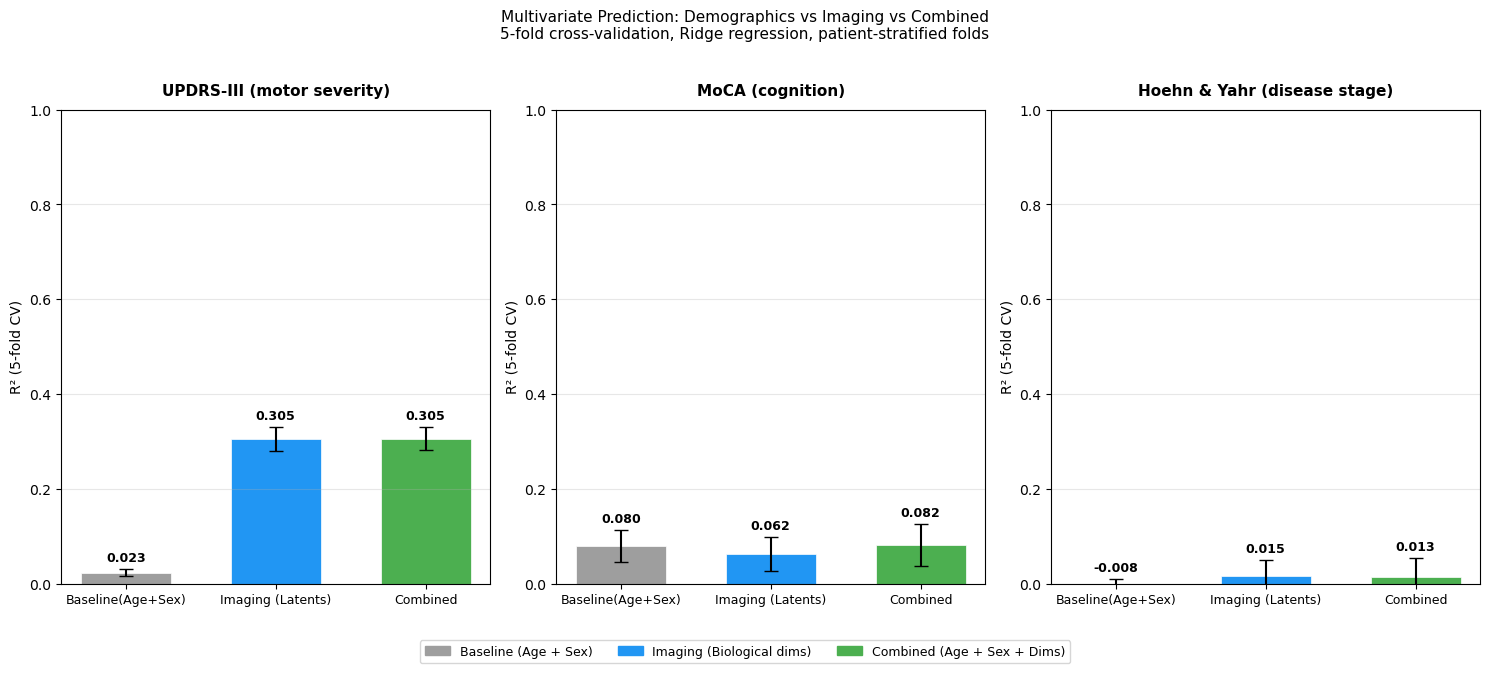

Saved: ../../results/figures/prediction_comparison_beta_3e5.png


In [30]:
# VISUALISATION
targets_available = [t for t in TARGETS.keys() if t in df_results['target'].values]
n_targets = len(targets_available)

fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 6), sharey=False)
if n_targets == 1:
    axes = [axes]

colors = {
    'Baseline (Age + Sex)':        '#9E9E9E',
    'Imaging (Biological dims)':   '#2196F3',
    'Combined (Age + Sex + Dims)': '#4CAF50',
}

for ax, target in zip(axes, targets_available):
    target_label = TARGETS[target]
    df_t = df_results[df_results['target'] == target]

    model_names = list(colors.keys())
    r2_means    = []
    r2_stds     = []
    bar_colors  = []

    for model in model_names:
        row = df_t[df_t['model'] == model]
        if len(row) == 0:
            r2_means.append(0)
            r2_stds.append(0)
        else:
            r2_means.append(row['r2_mean'].values[0])
            r2_stds.append(row['r2_std'].values[0])
        bar_colors.append(colors[model])

    x = np.arange(len(model_names))
    bars = ax.bar(x, r2_means, yerr=r2_stds, color=bar_colors,
                  capsize=5, width=0.6, edgecolor='white', linewidth=0.5)

    ax.set_title(target_label, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('R² (5-fold CV)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['Baseline(Age+Sex)', 'Imaging (Latents)', 'Combined'],
                       fontsize=9)
    finite_r2 = [v for v in r2_means if np.isfinite(v)]
    if len(finite_r2) > 0:
        ymax = max(finite_r2) * 1.3 + 0.05
        ymax = max(ymax, 1.0)
    else:
        ymax = 1.0
    ax.set_ylim(0, ymax)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)

    # Add R² values on bars
    for bar, r2, std in zip(bars, r2_means, r2_stds):
        if not np.isnan(r2):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                    f'{r2:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9)

fig.suptitle('Multivariate Prediction: Demographics vs Imaging vs Combined\n'
             '5-fold cross-validation, Ridge regression, patient-stratified folds',
             fontsize=11, y=1.02)

plt.tight_layout()
path = f'{FIGURES_DIR}/prediction_comparison_{BETA_SUFFIX}.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

## 7. Summary

In [31]:
# SUMMARY
print("=" * 65)
print("PREDICTION SUMMARY")
print("=" * 65)
print(f"\nMethod: Ridge regression, {N_FOLDS}-fold patient-stratified CV")
print(f"Biological dims used: {len(biological_dims)}")
print(f"\n{'Target':<30} {'Baseline R²':>12} {'Imaging R²':>12} {'Combined R²':>12} {'Improvement':>12}")
print("-" * 80)

for target, target_label in TARGETS.items():
    df_t = df_results[df_results['target'] == target]
    if len(df_t) == 0:
        continue
    r2_base = df_t[df_t['model'].str.startswith('Baseline')]['r2_mean'].values
    r2_img  = df_t[df_t['model'].str.startswith('Imaging')]['r2_mean'].values
    r2_comb = df_t[df_t['model'].str.startswith('Combined')]['r2_mean'].values

    r2_base = r2_base[0] if len(r2_base) > 0 else np.nan
    r2_img  = r2_img[0]  if len(r2_img)  > 0 else np.nan
    r2_comb = r2_comb[0] if len(r2_comb) > 0 else np.nan
    improvement = r2_comb - r2_base if not np.isnan(r2_comb) else np.nan

    print(f"  {target_label:<28} {r2_base:>12.3f} {r2_img:>12.3f} {r2_comb:>12.3f} {improvement:>+12.3f}")

print(f"\nOutputs saved to: {OUTPUT_DIR}/")

PREDICTION SUMMARY

Method: Ridge regression, 5-fold patient-stratified CV
Biological dims used: 75

Target                          Baseline R²   Imaging R²  Combined R²  Improvement
--------------------------------------------------------------------------------
  UPDRS-III (motor severity)          0.023        0.305        0.305       +0.283
  MoCA (cognition)                    0.080        0.062        0.082       +0.002
  Hoehn & Yahr (disease stage)       -0.008        0.015        0.013       +0.022

Outputs saved to: ../../results/prediction/


In [32]:

df_train = pd.read_csv(f'../../data/processed/clinical_merged/train_{BETA_SUFFIX}.csv')
df_sbr   = pd.read_csv('../../results/models/sbr_xing_pca_scores.csv')

print([c for c in df_train.columns if 'SBR' in c])

print("\nSBR scores file:")
print(df_sbr.columns.tolist())
print(df_sbr.shape)

['SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']

SBR scores file:
['PATNO', 'EVENT_ID', 'DATSCAN_DATE', 'SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']
(9949, 6)
